In [7]:
from calc_script import create_stats_df
from calc_script import create_plant_summary
from calc_script import create_a_summary_plot_ss_to_ss_comparison, create_a_summary_plot_rop_to_ss_comparison
from calc_script import export_df_to_excel_file
from IPython.display import display

In [8]:
START_DATE = '2025-10-20'
END_DATE = '2026-04-20'
# START_DATE = '2025-04-20'
# END_DATE = '2025-07-20'
GET_ALL_DATES_FROM_MB51 = False

PRODUCTION_PLANT = '2101'

# 95% -> k = 1.96 (most common choice)
# 96% -> k = 2,05 (best choice)
# 99% -> k = 2.33
K_PARAMETER = 2.05

STD_MAD_TRESHOLD = 2.5


In [9]:
exchange_rates = {
    'EUR': 1.0,
    'PLN': 0.23,  # Przykład: 1 PLN = 0.23 EUR
    'CZK': 0.04   # Przykład: 1 CZK = 0.04 EUR
}

mb51_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_Consumption.XLSX"
zsbe_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_items_and_parameters.XLSX"
no_ss_items_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\helper_files\no_ss_items.xlsx"

output_directory = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\output"
output_file_name = "output.xlsx"

In [10]:
stats_df = create_stats_df(mb51_path, zsbe_path, no_ss_items_path, PRODUCTION_PLANT, GET_ALL_DATES_FROM_MB51, START_DATE, END_DATE, K_PARAMETER, exchange_rates, STD_MAD_TRESHOLD)

Dates for calculations DatetimeIndex(['2025-10-20', '2025-10-21', '2025-10-22', '2025-10-23',
               '2025-10-24', '2025-10-27', '2025-10-28', '2025-10-29',
               '2025-10-30', '2025-10-31',
               ...
               '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10',
               '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16',
               '2026-04-17', '2026-04-20'],
              dtype='datetime64[ns]', length=131, freq='B')


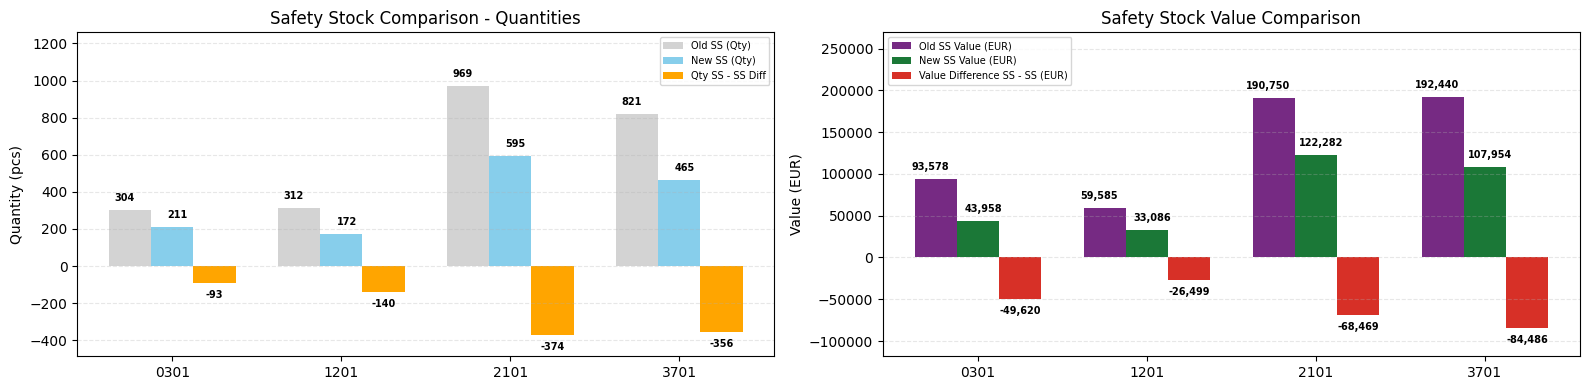

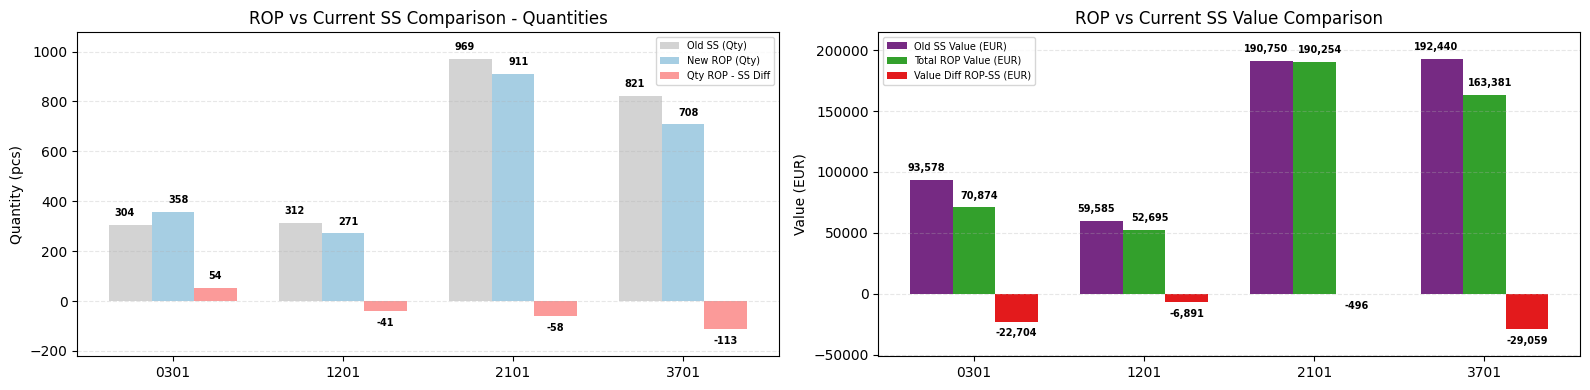

In [11]:
plant_summary = create_plant_summary(stats_df)
fig_ss = create_a_summary_plot_ss_to_ss_comparison(plant_summary)
fig_rop = create_a_summary_plot_rop_to_ss_comparison(plant_summary)
display(fig_ss)
display(fig_rop)

In [12]:
export_df_to_excel_file(stats_df, fr"{output_directory}\{output_file_name}")